<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Persiapan & Pemahaman Data

## Install & Import Library

In [1]:
!pip install kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setup Kaggle API & Download Dataset

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d redwankarimsony/heart-disease-data

!unzip heart-disease-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
100% 12.4k/12.4k [00:00<00:00, 24.6MB/s]

Archive:  heart-disease-data.zip
  inflating: heart_disease_uci.csv   


## Load dataset

In [4]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Memahami Ukuran & Struktur Data

In [5]:
print("Shape:", df.shape)

print("\nInfo:")
df.info()

df.describe()

Shape: (920, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Memahami Makna Setiap Kolom

In [6]:
kolom_info = {
    'id': 'ID unik pasien',
    'age': 'Usia pasien (tahun)',
    'sex': 'Jenis kelamin (Male/Female)',
    'dataset': 'Asal dataset (kota/negara)',
    'cp': 'Tipe nyeri dada (typical angina, atypical angina, non-anginal, asymptomatic)',
    'trestbps': 'Tekanan darah saat istirahat (mm Hg)',
    'chol': 'Kadar kolesterol serum (mg/dl)',
    'fbs': 'Gula darah puasa > 120 mg/dl (True/False)',
    'restecg': 'Hasil EKG saat istirahat',
    'thalach': 'Detak jantung maksimum yang dicapai',
    'exang': 'Angina akibat olahraga (True/False)',
    'oldpeak': 'Depresi ST akibat olahraga relatif terhadap istirahat',
    'slope': 'Kemiringan segmen ST puncak olahraga',
    'ca': 'Jumlah pembuluh darah utama (0-3) hasil fluoroskopi',
    'thal': 'Hasil tes thalassemia',
    'num': 'Target: diagnosis penyakit jantung (0 = tidak ada, 1-4 = ada)'
}

for col, desc in kolom_info.items():
  print(f"{col:12} : {desc}")

id           : ID unik pasien
age          : Usia pasien (tahun)
sex          : Jenis kelamin (Male/Female)
dataset      : Asal dataset (kota/negara)
cp           : Tipe nyeri dada (typical angina, atypical angina, non-anginal, asymptomatic)
trestbps     : Tekanan darah saat istirahat (mm Hg)
chol         : Kadar kolesterol serum (mg/dl)
fbs          : Gula darah puasa > 120 mg/dl (True/False)
restecg      : Hasil EKG saat istirahat
thalach      : Detak jantung maksimum yang dicapai
exang        : Angina akibat olahraga (True/False)
oldpeak      : Depresi ST akibat olahraga relatif terhadap istirahat
slope        : Kemiringan segmen ST puncak olahraga
ca           : Jumlah pembuluh darah utama (0-3) hasil fluoroskopi
thal         : Hasil tes thalassemia
num          : Target: diagnosis penyakit jantung (0 = tidak ada, 1-4 = ada)


## Cek missing values

In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct.round(2)
})

print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing (%)
trestbps             59         6.41
chol                 30         3.26
fbs                  90         9.78
restecg               2         0.22
thalch               55         5.98
exang                55         5.98
oldpeak              62         6.74
slope               309        33.59
ca                  611        66.41
thal                486        52.83


# Fase 2: Eksplorasi & Visualisasi Data (EDA)

## Membuat Kolom Target Biner

In [8]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print(df['target'].value_counts())
print('\nPersentase:')
print(df['target'].value_counts(normalize=True) * 100)

target
1    509
0    411
Name: count, dtype: int64

Persentase:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64


## Melihat distribusi target

/tmp/ipykernel_8910/3118608863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=df, palette="Set2")


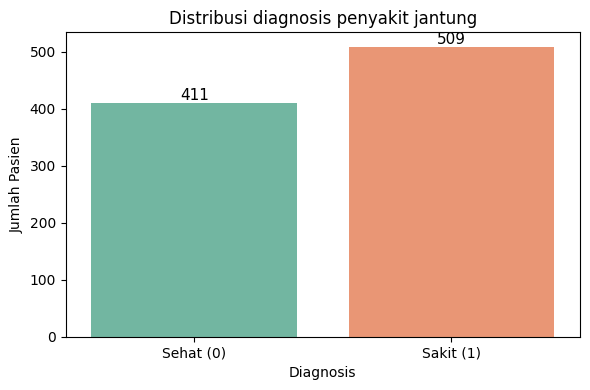

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="target", data=df, palette="Set2")
plt.title("Distribusi diagnosis penyakit jantung")
plt.xticks([0, 1], ["Sehat (0)", "Sakit (1)"])
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah Pasien")

for p in ax.patches:
  ax.annotate(f"{int(p.get_height())}",
    (p.get_x() + p.get_width() / 2., p.get_height()),
    ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

## Melihat distribusi fitur numerik

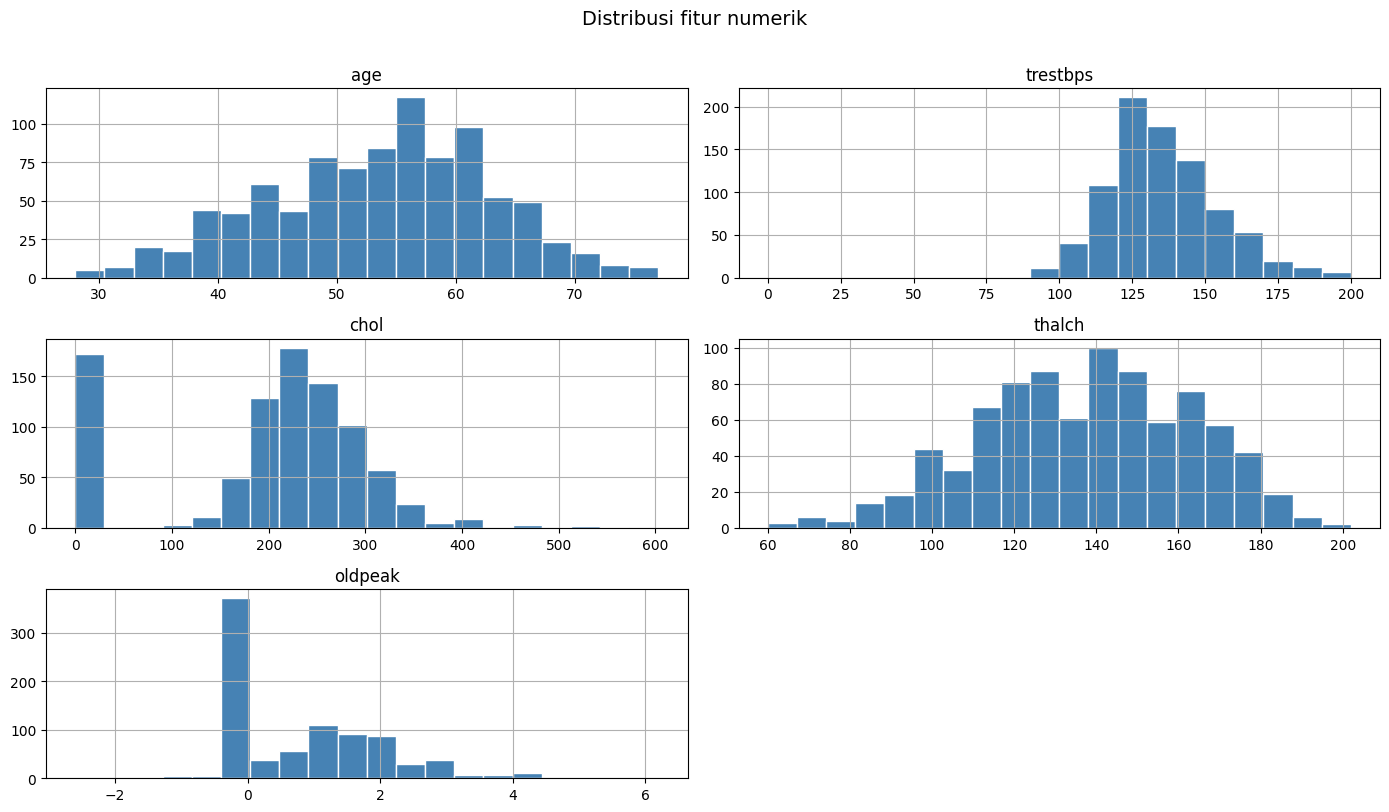

In [10]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

df[num_cols].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribusi fitur numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Membandingkan fitur numerik vs target

/tmp/ipykernel_8910/580831836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', data=df, y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8910/580831836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', data=df, y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8910/580831836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', data=df, y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8910/580831836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

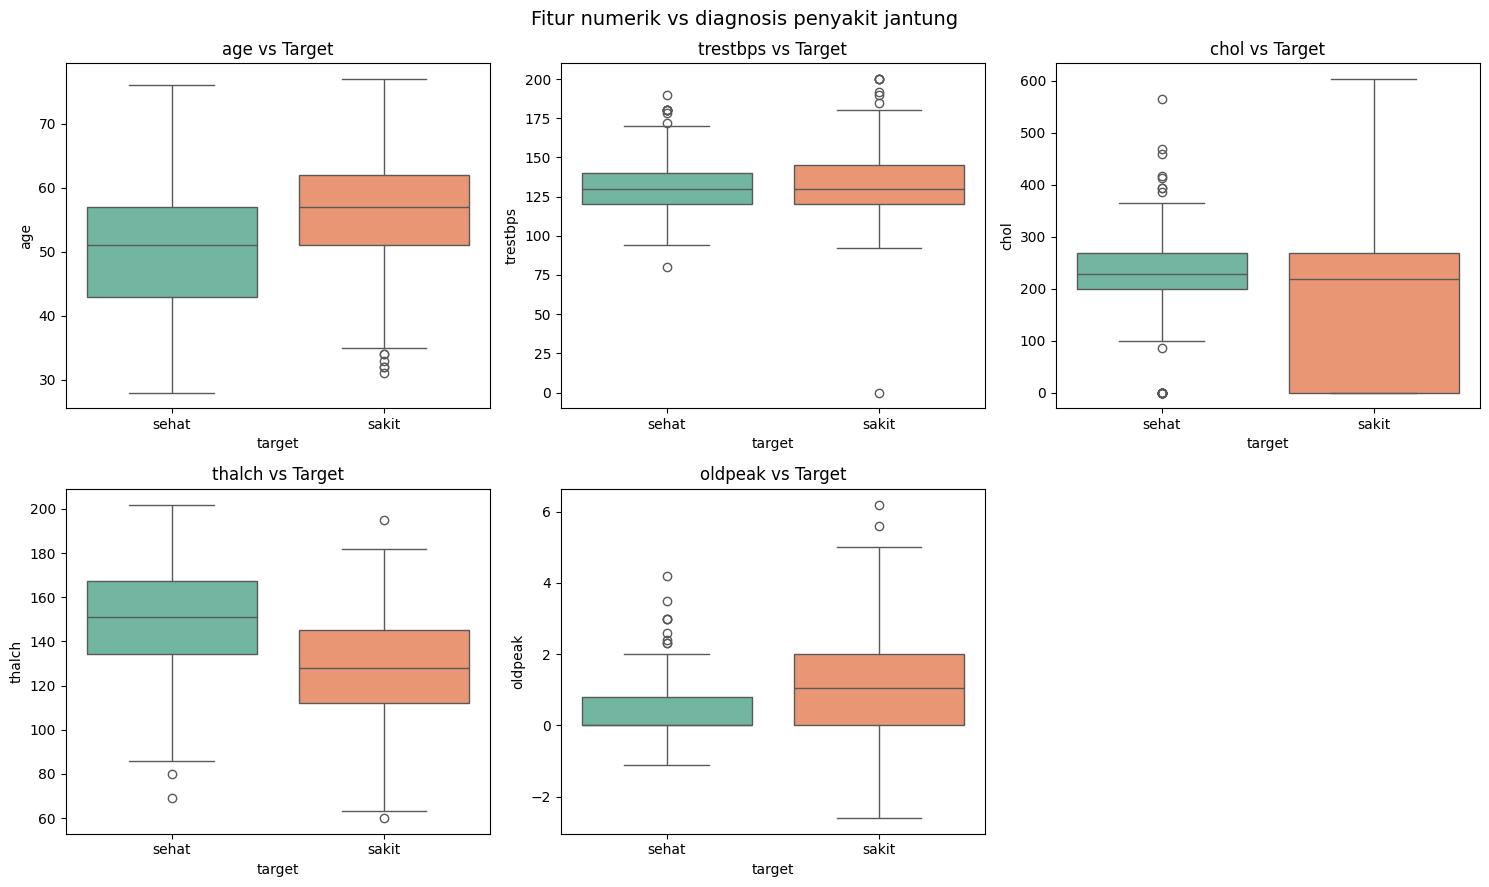

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.boxplot(x='target', data=df, y=col, palette='Set2', ax=axes[i])
  axes[i].set_title(f'{col} vs Target')
  axes[i].set_xticks([0, 1])
  axes[i].set_xticklabels(['sehat', 'sakit'])

axes[-1].set_visible(False)
plt.suptitle('Fitur numerik vs diagnosis penyakit jantung', fontsize=14)
plt.tight_layout()
plt.show()

## Membandingkan distribusi fitur kategorikal vs target

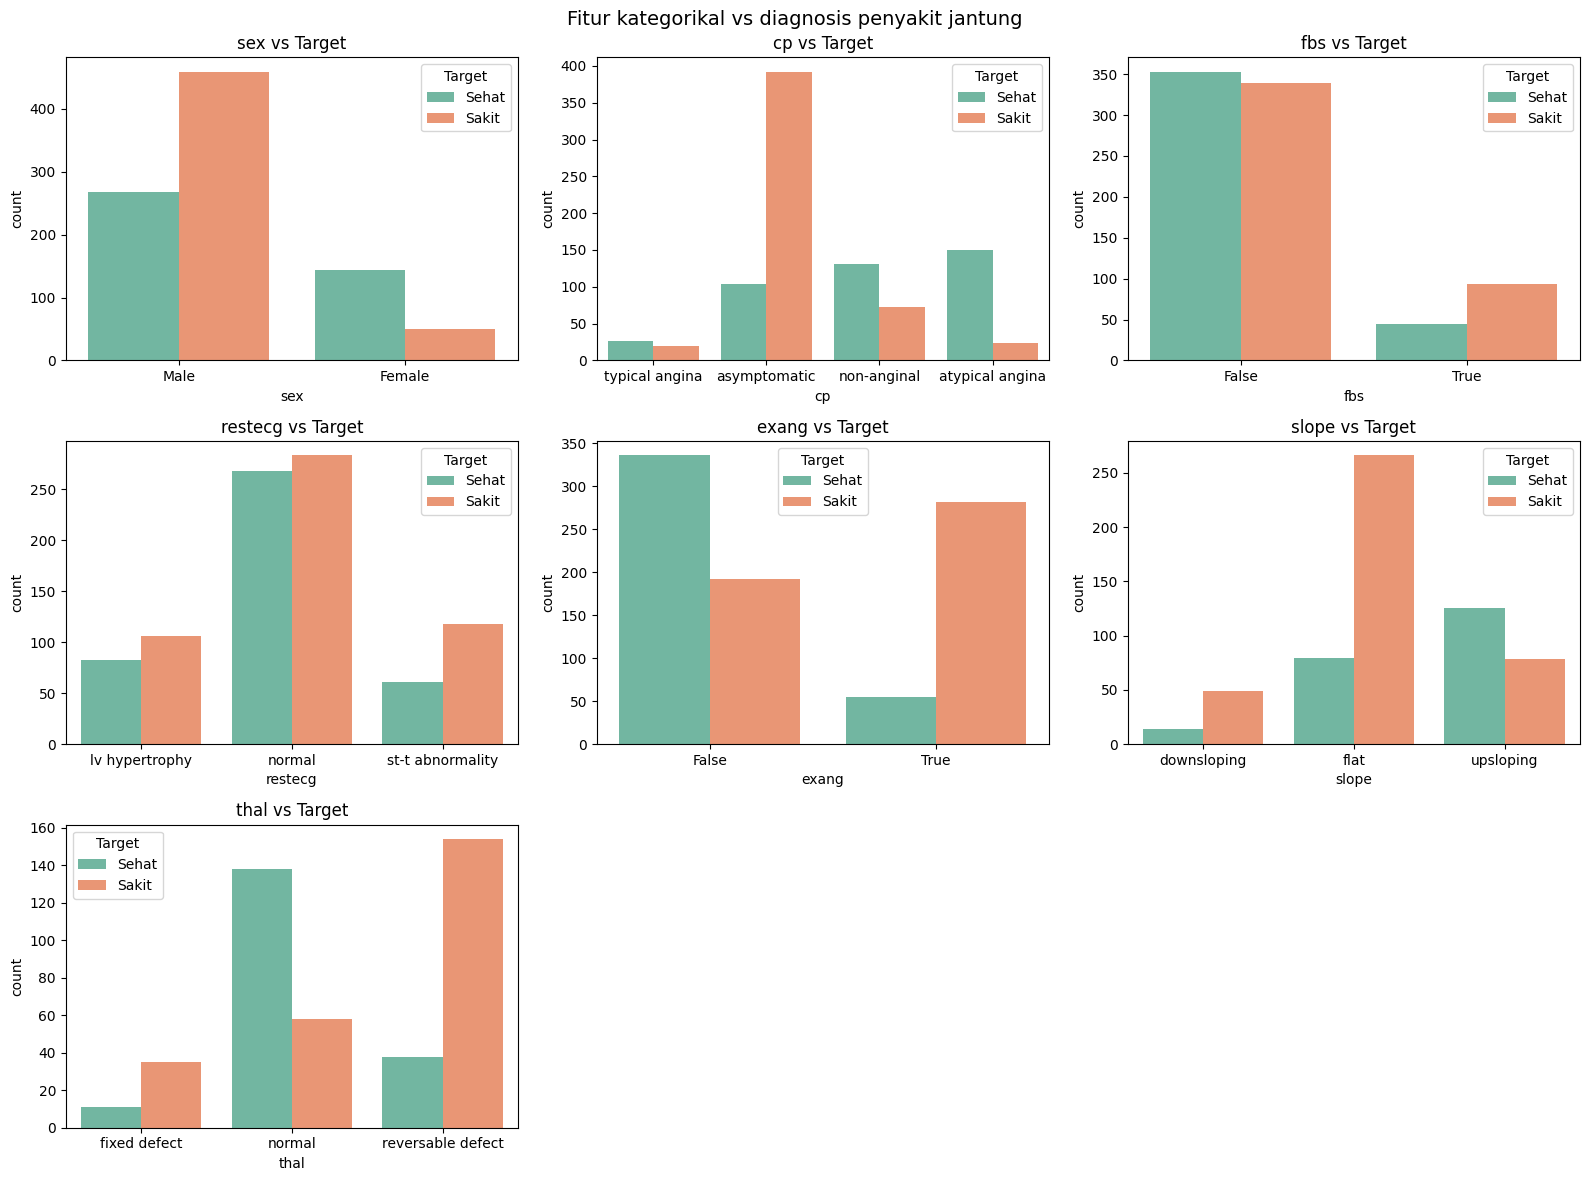

In [12]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  sns.countplot(x=col, hue='target', data=df, palette="Set2", ax=axes[i])
  axes[i].set_title(f'{col} vs Target')
  axes[i].legend(title='Target', labels=['Sehat', 'Sakit'])

for j in range(i + 1, len(axes)):
  axes[j].set_visible(False)

plt.suptitle('Fitur kategorikal vs diagnosis penyakit jantung', fontsize=14)
plt.tight_layout()
plt.show()

## Menampilkan heatmap korelasi antar fitur

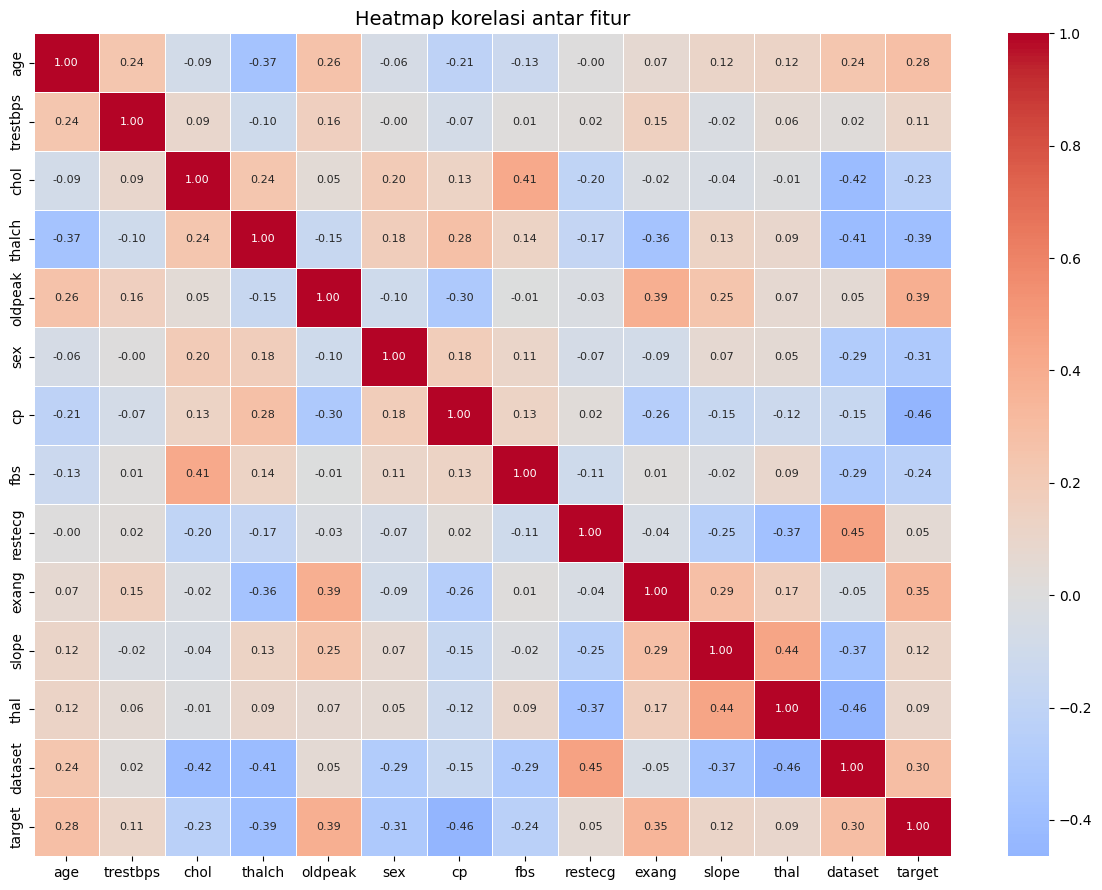

In [13]:
df_encoded = df.copy()
cat_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']

for col in cat_to_encode:
  df_encoded[col] = pd.factorize(df_encoded[col])[0]

corr_cols = num_cols + cat_to_encode + ['target']
corr_matrix = df_encoded[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap korelasi antar fitur', fontsize=14)
plt.tight_layout()
plt.show()

## Ringkasan temuan EDA

In [14]:
corr_with_target = corr_matrix['target'].drop('target').sort_values(ascending=False)

print('Korelasi fitur terhadap target (descending)')
print(corr_with_target.round(3))

Korelasi fitur terhadap target (descending)
oldpeak     0.386
exang       0.345
dataset     0.296
age         0.283
slope       0.115
trestbps    0.106
thal        0.091
restecg     0.052
chol       -0.231
fbs        -0.236
sex        -0.307
thalch     -0.395
cp         -0.459
Name: target, dtype: float64


# Fase 3: Preprocessing Data

## Menghapus kolom yang tidak diperlukan

In [15]:
df_clean = df.drop(columns=['id', 'dataset', 'num'])

print('Kolom setelah drop', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Kolom setelah drop ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Shape: (920, 14)
